## arXiv corpus — read this first

This is the **arXiv** twin of the S2ORC notebook, generated by
`accelscan.scripts.make_arxiv_notebooks`. Edit the S2ORC original and regenerate.

Four things make arXiv levels **not** comparable to S2ORC levels:

1. **Self-selected preprints**, skewed to physics and CS, with no peer-review filter.
2. **Raw-LaTeX matching.** The matcher reads the `.tex` source, which includes figure
   captions, spec tables, code listings and `%` comments that GROBID drops from
   S2ORC. This biases any-mention prevalence *upward*; `reported use` and
   model-specific series are better protected because the LLM judges the passage.
3. **No citations.** There is no arXiv→corpusid crosswalk, so §6.4-style citation
   analyses are absent here.
4. **1991–2026 available, 2005–2026 analysed.** 2026 is a partial calendar year:
   fine for shares, marked on counts.

Only **within-corpus trends** should be compared across the two corpora.


# §6 Device Productivity — the chip as the unit of analysis

Answers the draft's questions directly: how fast are new chips taken up, how
long do they stay productive, and how many papers / citations does each chip
support?

* **6.1 Paper support** — papers per device model. A paper counts once for
  every model it reports, so a paper naming k models supports all k: credit is a
  count of supporting papers, never a 1/k split.
* **6.2 Productive half-life** — years from a model's peak share of
  accelerator-using papers until it sustainedly falls below half of that peak,
  with bootstrap CIs and right-censoring. The 3–5 year grant cycle is the
  policy-relevant benchmark for buy-vs-rent decisions, discussed in the text.
* **6.3 Adoption lag** — release date → first mention → 10th/100th paper, by
  hardware generation: is diffusion into science speeding up?
* **6.4 Citation support** — 3-year citations (`i_3`) per model, on the same
  counting rule. The shorter citation window admits more recent papers, and
  therefore more recent accelerators.

> Descriptive attribution, not causal: a paper crediting a chip is not evidence
> the chip caused the result. Because each supporting paper is counted once per
> model it names, per-model counts sum to more than the number of papers — that
> is the intended semantics, not double counting to be corrected away.

Inputs: `python -m accelscan.denominator` and `python -m accelscan.compute`.

In [1]:
%matplotlib inline
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from accelscan.config import BUCKET, OUT_PREFIX
from accelscan.normalize import canonicalize_column
from accelscan.registry import load_registry
from accelscan.s3 import mentions_glob, storage_options
from accelscan.plotting import setup_figures, spread_labels
from accelscan.meta import paper_fields
from accelscan.paths import (analytic_base, candidates_root, capacity_key,
                             get_corpus, precision_key, s3_uri)

# integer year ticks + every figure exported to output/analysis/productivity/
setup_figures('arxiv/productivity')

## Knobs

In [2]:
MODEL_TAG, PROMPT_VERSION = 'qwen3-14b', 'p1'
YEAR_MIN, YEAR_MAX = 2005, 2026
USED_ONLY = True            # restrict to used-in-this-work mentions
MIN_PAPERS_MODEL = 100      # eligibility for lifecycle estimates (plan: 100; robustness 50/250)
SMOOTH = 3                  # years in the moving average for half-life
BOOTSTRAP = 200
LOCAL_ANALYTIC = None

PAL = ['#0072B2', '#D55E00', '#009E73', '#CC79A7', '#E69F00', '#56B4E9', '#999999',
       '#000000', '#984EA3', '#44AA99']
reg = load_registry(); so = storage_options()
CORPUS = 'arxiv'
c = get_corpus(CORPUS); KEY = c.key      # 'paper_id'; corpusid is null for arXiv

# arXiv's group names are too long for legends and axis ticks. Applied at every point
# `field` enters, so the short form is what every figure and table shows.
FIELD_LABELS = {'Electrical Engineering and Systems Science': 'EE and Systems',
                'Quantitative Biology': 'Quant. Biology',
                'Quantitative Finance': 'Quant. Finance'}
short_fields = lambda df: df.with_columns(pl.col('field').replace(FIELD_LABELS))


## Load paper×model observations + outcomes

In [3]:
base = (LOCAL_ANALYTIC or
        s3_uri(analytic_base(c, reg.version, PROMPT_VERSION, MODEL_TAG)))
rd = (lambda n: pl.read_parquet(f'{base}/{n}.parquet')) if LOCAL_ANALYTIC else \
     (lambda n: pl.read_parquet(f'{base}/{n}.parquet', storage_options=so))
den = short_fields(rd('denominator')).select(KEY, 'year', 'field')
# no citations for arXiv: there is no arXiv->corpusid crosswalk

m = (pl.scan_parquet(mentions_glob(MODEL_TAG, PROMPT_VERSION, corpus=c), storage_options=so)
     .filter(pl.col('status') == 'ok')
     .select(KEY, 'model_normalized', 'manufacturer', 'usage_context')
     .collect())
if USED_ONLY:
    m = m.filter(pl.col('usage_context') == 'used-in-this-work')
m = canonicalize_column(m, reg).filter(pl.col('canonical_kind') == 'model')

meta = pl.DataFrame(
    [{'canonical_model': x.id, 'display': x.display, 'manufacturer_reg': x.manufacturer,
      'segment': x.segment, 'architecture': x.architecture,
      'release_year': int(x.release[:4]) if x.release else None,
      'release_ym': x.release, 'fp32_gflops': x.fp32_gflops}
     for x in reg.models.values() if x.kind == 'model'],
    schema={'canonical_model': pl.Utf8, 'display': pl.Utf8, 'manufacturer_reg': pl.Utf8,
            'segment': pl.Utf8, 'architecture': pl.Utf8, 'release_year': pl.Int32,
            'release_ym': pl.Utf8, 'fp32_gflops': pl.Float64})

# one row per (paper, model): a paper supports every model it reports, so these
# rows ARE the credit units (k rows for a paper naming k models)
pm = (m.select(KEY, 'canonical_model').unique()
      .join(den, on=KEY, how='inner')
      .filter(pl.col('year').is_between(YEAR_MIN, YEAR_MAX)))
pm = (pm.join(pm.group_by(KEY).agg(n_models=pl.len()), on=KEY)
      .join(meta, on='canonical_model', how='left'))
print(f'{pm.height:,} paper-model observations | {pm.n_unique(KEY):,} papers '
      f'| {pm.n_unique("canonical_model"):,} models')

198,141 paper-model observations | 175,067 papers | 378 models


## 6.1 Paper support per device model

**Left — volume:** total papers supported, the raw count of supporting papers.
Structurally biased toward chips that have been available longer.

**Right — rate:** papers supported per year of observable life, i.e. total support
divided by the years from release to the end of the window
(`YEAR_MAX - max(release_year, YEAR_MIN) + 1`). This is the age-normalised measure:
it answers "while this chip existed, how much science did it carry per year?", which
is what makes a 2023 part comparable to a 2014 one.

The two panels are ranked **independently**, so they surface different chips on
purpose — a long-lived workhorse can top the volume panel while a recent part tops
the rate panel. Exposure is truncated on both sides: a chip released before
`YEAR_MIN` gets credit only from `YEAR_MIN`, and every chip's window ends at
`YEAR_MAX`, so the newest parts' rates rest on one or two years and are the least
stable. Models with no registry release date are excluded from the rate panel only.


91 models meet the >=100-paper eligibility bar


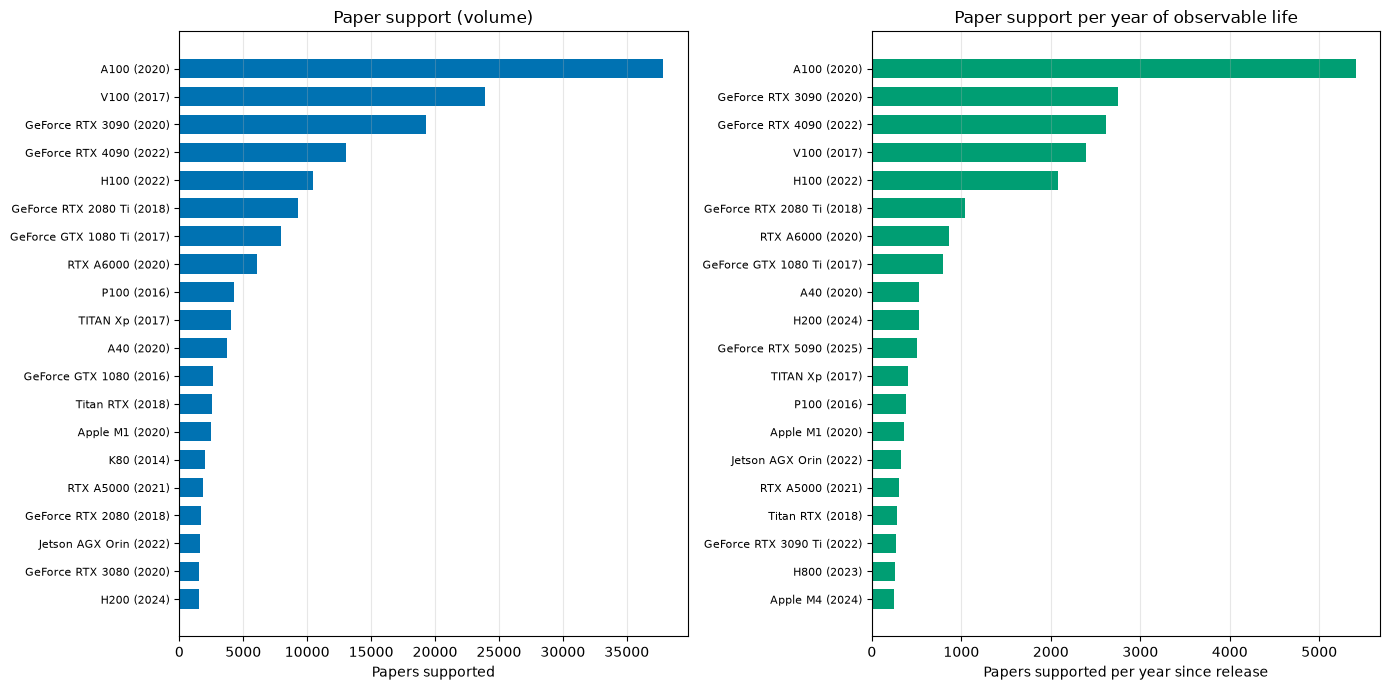

shape: (25, 6)
┌──────────────────────────┬──────────────┬────────┬────────────────┬─────────────────┬────────────┐
│ display                  ┆ release_year ┆ papers ┆ exposure_years ┆ papers_per_year ┆ first_year │
│ ---                      ┆ ---          ┆ ---    ┆ ---            ┆ ---             ┆ ---        │
│ str                      ┆ i32          ┆ u32    ┆ i32            ┆ f64             ┆ i32        │
╞══════════════════════════╪══════════════╪════════╪════════════════╪═════════════════╪════════════╡
│ NVIDIA A100              ┆ 2020         ┆ 37859  ┆ 7              ┆ 5408.4          ┆ 2019       │
│ NVIDIA GeForce RTX 3090  ┆ 2020         ┆ 19292  ┆ 7              ┆ 2756.0          ┆ 2020       │
│ NVIDIA GeForce RTX 4090  ┆ 2022         ┆ 13075  ┆ 5              ┆ 2615.0          ┆ 2022       │
│ NVIDIA V100              ┆ 2017         ┆ 23924  ┆ 10             ┆ 2392.4          ┆ 2016       │
│ NVIDIA H100              ┆ 2022         ┆ 10424  ┆ 5              ┆ 2084.8

In [4]:
sup = (pm.group_by('canonical_model', 'display', 'release_year', 'segment', 'architecture')
       .agg(papers=pl.len(),
            first_year=pl.col('year').min(), peak_year_raw=pl.col('year').mode().first())
       .sort('papers', descending=True))
# Observable lifetime: release -> end of window, clipped to the window's start so
# pre-YEAR_MIN chips are not credited with years the corpus does not cover.
# max_horizontal ignores nulls, so an unknown release date would silently inherit
# YEAR_MIN and get a full-window exposure: keep it null instead of inventing a rate
sup = sup.with_columns(
    exposure_years=pl.when(pl.col('release_year').is_not_null())
    .then((YEAR_MAX - pl.max_horizontal('release_year', pl.lit(YEAR_MIN)) + 1).clip(1, None))
    .otherwise(None).cast(pl.Int32))
sup = sup.with_columns(papers_per_year=pl.col('papers') / pl.col('exposure_years'))
elig = sup.filter(pl.col('papers') >= MIN_PAPERS_MODEL)
print(f'{elig.height} models meet the >={MIN_PAPERS_MODEL}-paper eligibility bar')

def barh_panel(ax, d, col, xlabel, title, color):
    y = np.arange(d.height)
    ax.barh(y, d[col], 0.7, color=color)
    ax.set_yticks(y)
    ax.set_yticklabels([f"{s.replace('NVIDIA ', '')} ({r})" for s, r in
                        zip(d['display'], d['release_year'])], fontsize=8)
    ax.invert_yaxis(); ax.set(xlabel=xlabel, title=title)
    ax.grid(alpha=0.3, axis='x')

top = elig.head(20)
rate = (elig.filter(pl.col('release_year').is_not_null())
        .sort('papers_per_year', descending=True).head(20))
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
# ranked independently: volume favours long-available chips, the rate is age-normalised
barh_panel(axes[0], top, 'papers', 'Papers supported',
           'Paper support (volume)', '#0072B2')
barh_panel(axes[1], rate, 'papers_per_year', 'Papers supported per year since release',
           'Paper support per year of observable life', '#009E73')
plt.tight_layout(); plt.show()
with pl.Config(tbl_rows=25, fmt_str_lengths=40):
    print(elig.sort('papers_per_year', descending=True, nulls_last=True)
          .select('display', 'release_year', 'papers', 'exposure_years',
                  pl.col('papers_per_year').round(1), 'first_year').head(25))

### 6.1b Paper support over a device's life

Where 6.1 gives each chip a single number, this shows the shape of its support over
time: papers supported per year on a log axis, plotted against **years since
release** so the lifecycles align — a 2014 chip and a 2023 chip become directly
comparable instead of sitting in different parts of a calendar axis.

Log scale because support spans orders of magnitude across these models, and because
on a log axis equal *slopes* mean equal *growth rates*: the ramp-up and decay phases
can be compared between chips even when their levels differ 100-fold. Levels are
readable too, unlike the indexed version this replaced — the vertical gap between two
lines is the ratio of papers they carry.

Lines are ordered by release year and **dashed for the earlier half of the models,
solid for the later half**, so "do newer chips ramp faster and fall off sooner?" is a
comparison of dashed against solid. Color is unique within each style group, so a
(color, style) pair identifies a model. Years with zero supporting papers are absent
rather than plotted at zero, which a log axis cannot show.


/tmp/ipykernel_2111232/4046296967.py:4: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  ts = (pm.filter(pl.col('canonical_model').is_in(tm['canonical_model']))


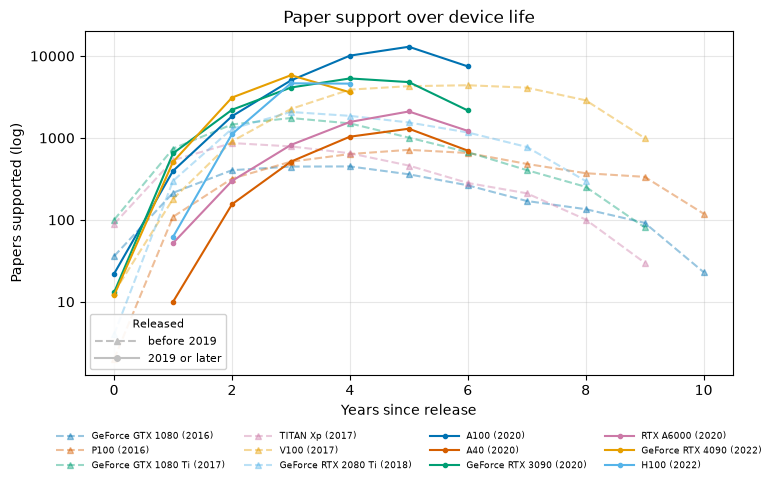

shape: (12, 6)
┌───────────────────┬──────────────┬─────────────┬──────────────────┬─────────────┬────────────────┐
│ display           ┆ release_year ┆ peak_papers ┆ peak_since_relea ┆ last_papers ┆ years_observed │
│ ---               ┆ ---          ┆ ---         ┆ se               ┆ ---         ┆ ---            │
│ str               ┆ i32          ┆ u32         ┆ ---              ┆ u32         ┆ u32            │
│                   ┆              ┆             ┆ i32              ┆             ┆                │
╞═══════════════════╪══════════════╪═════════════╪══════════════════╪═════════════╪════════════════╡
│ NVIDIA GeForce    ┆ 2016         ┆ 449         ┆ 4                ┆ 23          ┆ 11             │
│ GTX 1080          ┆              ┆             ┆                  ┆             ┆                │
│ NVIDIA P100       ┆ 2016         ┆ 716         ┆ 5                ┆ 119         ┆ 11             │
│ NVIDIA GeForce    ┆ 2017         ┆ 1750        ┆ 3                ┆ 81    

In [5]:
TOP_N_CHANGE = 12

tm = elig.sort('papers', descending=True).head(TOP_N_CHANGE)
ts = (pm.filter(pl.col('canonical_model').is_in(tm['canonical_model']))
      .group_by('canonical_model', 'year').agg(papers=pl.len())
      .join(tm.select('canonical_model', 'display', 'release_year'), on='canonical_model')
      .filter(pl.col('release_year').is_not_null()
              & (pl.col('year') >= pl.col('release_year'))
              & (pl.col('papers') > 0))          # log axis cannot show a zero year
      .with_columns(since_release=pl.col('year') - pl.col('release_year'))
      .sort('canonical_model', 'year'))

order = tm.filter(pl.col('release_year').is_not_null()).sort('release_year', 'display')
split = order['release_year'].median()      # earlier half dashed, later half solid
fig, ax = plt.subplots(figsize=(8, 5))
# separate color counters per style group, so colors are unique WITHIN a group and
# a (color, style) pair identifies a model
seen = {True: 0, False: 0}
for r in order.iter_rows(named=True):
    s = ts.filter(pl.col('canonical_model') == r['canonical_model']).sort('year')
    if s.height < 2:
        continue
    early = r['release_year'] < split
    idx = seen[early]; seen[early] += 1
    # marker carries the era too, so the two groups separate even where a dash
    # pattern is hard to see at legend scale
    ax.plot(s['since_release'], s['papers'], ms=4 if early else 3,
            marker='^' if early else 'o', ls='--' if early else '-',
            color=PAL[idx % len(PAL)],
            alpha=0.4 if early else 1,
            label=f"{r['display'].replace('NVIDIA ', '')} ({r['release_year']})")
ax.set_yscale('log')
ax.yaxis.set_major_formatter(lambda v, _: f'{v:g}')
ax.set(xlabel='Years since release', ylabel='Papers supported (log)',
       title=f'Paper support over device life')
# Two legends. The first states the encoding itself -- with 15 entries at 6.5pt the
# per-model handles are too short to read a dash pattern off, so the era split gets
# its own oversized handles; the second identifies the models.
era = [plt.Line2D([], [], color='#C1C1C1', ls='--', marker='^', ms=5,
                  label=f'before {int(split)}'),
       plt.Line2D([], [], color="#C1C1C1", ls='-', marker='o', ms=4,
                  label=f'{int(split)} or later')]
ax.add_artist(ax.legend(handles=era, fontsize=8, loc='lower left', handlelength=4,
                        title='Released', title_fontsize=8, framealpha=0.9))
# below the axes: the plot area itself is full of overlapping lines
ax.legend(fontsize=6.5, ncol=4, loc='upper center', bbox_to_anchor=(0.5, -0.14),
          frameon=False, handlelength=3.2)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

with pl.Config(tbl_rows=30, fmt_str_lengths=34):
    print(ts.group_by('display', 'release_year')
          .agg(peak_papers=pl.col('papers').max(),
               peak_since_release=pl.col('since_release')
               .filter(pl.col('papers') == pl.col('papers').max()).first(),
               last_papers=pl.col('papers').filter(pl.col('year') == pl.col('year').max()).first(),
               years_observed=pl.len())
          .sort('release_year', 'display'))

## 6.2 Productive half-life

A model's share of accelerator-using papers each year, `SMOOTH`-year moving
average. Peak year = argmax of the smoothed share. Half-life = first h such
that the smoothed share stays at or below half the peak for two consecutive
observed years. Models never crossing by the last year are **right-censored**
and reported as `H > x` rather than dropped (dropping them would bias half-lives
downward — the survivors are exactly the long-lived chips).

The policy benchmark stays in the text rather than on the figure: a typical grant
runs 3-5 years, so a median half-life inside that band means hardware bought at
the start of an award is already past peak scientific productivity before the
award ends — the core of the buy-vs-rent argument. Read the median off the table
below and compare it to that range.


83 models: 46 with observed half-life, 37 right-censored
median observed half-life: 3.0 years


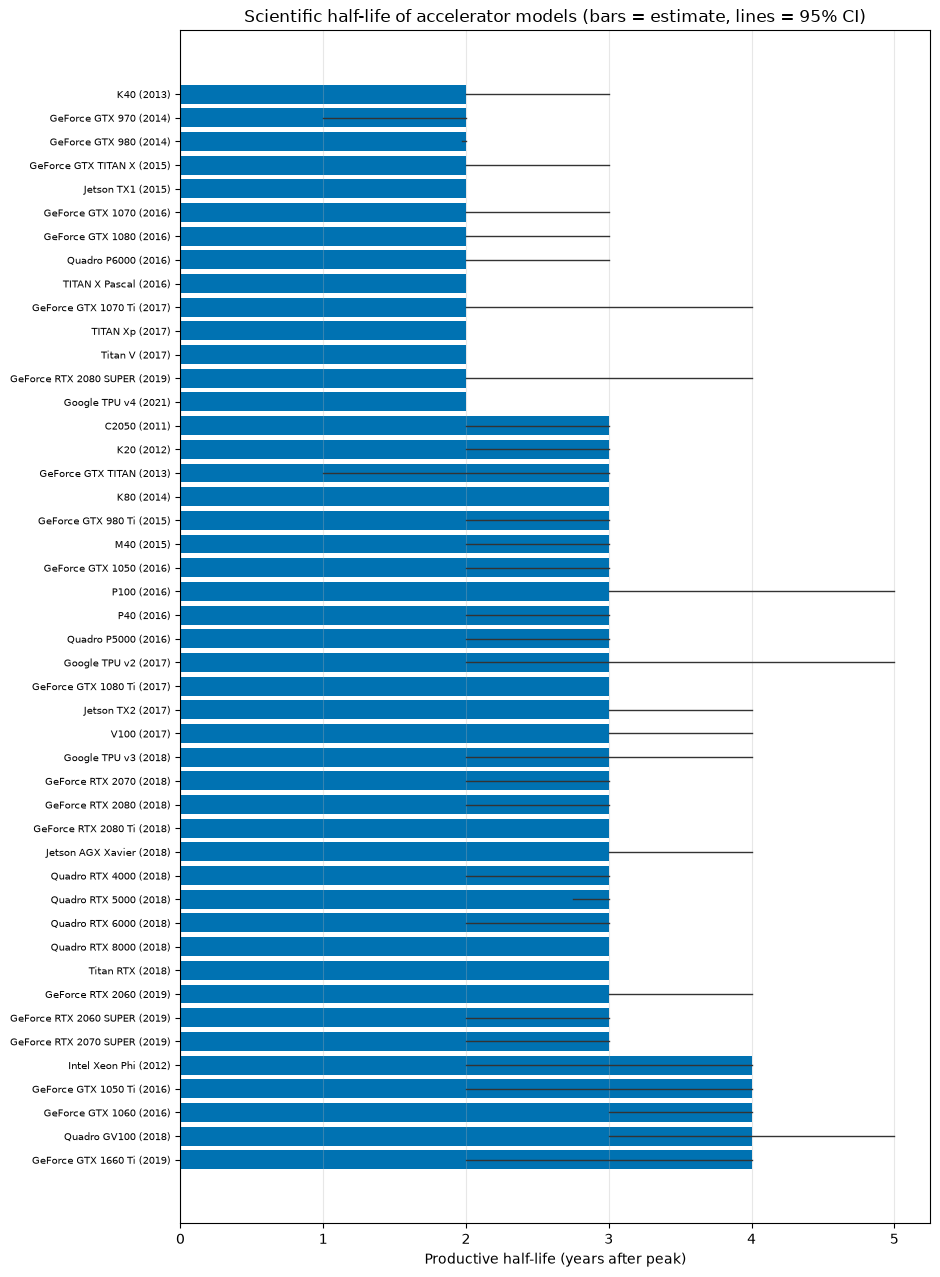

shape: (83, 7)
┌───────────────────┬──────────────┬───────────┬───────────────┬───────────┬──────────┬────────────┐
│ display           ┆ release_year ┆ peak_year ┆ years_to_peak ┆ half_life ┆ censored ┆ peak_share │
│ ---               ┆ ---          ┆ ---       ┆ ---           ┆ ---       ┆ ---      ┆ ---        │
│ str               ┆ i64          ┆ i64       ┆ i64           ┆ i64       ┆ bool     ┆ f64        │
╞═══════════════════╪══════════════╪═══════════╪═══════════════╪═══════════╪══════════╪════════════╡
│ NVIDIA C2050      ┆ 2011         ┆ 2011      ┆ 0             ┆ 3         ┆ false    ┆ 0.1531     │
│ Intel Xeon Phi    ┆ 2012         ┆ 2014      ┆ 2             ┆ 4         ┆ false    ┆ 0.0748     │
│ NVIDIA K20        ┆ 2012         ┆ 2014      ┆ 2             ┆ 3         ┆ false    ┆ 0.0898     │
│ NVIDIA GeForce    ┆ 2013         ┆ 2014      ┆ 1             ┆ 3         ┆ false    ┆ 0.0746     │
│ GTX TITAN         ┆              ┆           ┆               ┆           ┆

In [6]:
per_year = pm.group_by('year').agg(accel_papers=pl.col(KEY).n_unique())
shares = (pm.group_by('canonical_model', 'year').agg(k=pl.col(KEY).n_unique())
          .join(per_year, on='year')
          .with_columns(share=pl.col('k') / pl.col('accel_papers')))

def smooth(v: np.ndarray, w: int = SMOOTH) -> np.ndarray:
    if w <= 1 or v.size < w:
        return v
    ker = np.ones(w) / w
    return np.convolve(v, ker, mode='same')

def half_life(years: np.ndarray, sh: np.ndarray, persist: int = 2):
    """-> (peak_year, peak_share, half_life or None if censored)"""
    sm = smooth(sh)
    pi = int(np.argmax(sm))
    peak, py = sm[pi], years[pi]
    thr = peak / 2
    below = 0
    for j in range(pi + 1, len(years)):
        below = below + 1 if sm[j] <= thr else 0
        if below >= persist:
            return py, peak, int(years[j - persist + 1] - py)
    return py, peak, None

rows = []
for mid in elig['canonical_model']:
    s = shares.filter(pl.col('canonical_model') == mid).sort('year')
    if s.height < 4:
        continue
    yy = s['year'].to_numpy(); vv = s['share'].to_numpy().astype(float)
    py, peak, hl = half_life(yy, vv)
    boots = []
    rng = np.random.default_rng(0)
    for _ in range(BOOTSTRAP):
        jitter = rng.poisson(np.maximum(s['k'].to_numpy(), 0)).astype(float)
        tot = s['accel_papers'].to_numpy().astype(float)
        _, _, h = half_life(yy, np.divide(jitter, tot, out=np.zeros_like(tot), where=tot > 0))
        if h is not None:
            boots.append(h)
    d = meta.filter(pl.col('canonical_model') == mid)
    rows.append({'canonical_model': mid, 'display': d['display'][0],
                 'release_year': d['release_year'][0], 'segment': d['segment'][0],
                 'peak_year': int(py), 'peak_share': float(peak),
                 'half_life': hl, 'censored': hl is None,
                 'hl_lo': float(np.percentile(boots, 2.5)) if boots else None,
                 'hl_hi': float(np.percentile(boots, 97.5)) if boots else None,
                 'years_to_peak': int(py - d['release_year'][0]) if d['release_year'][0] else None})
hl = pl.DataFrame(rows).sort('release_year', 'display')
obs = hl.filter(~pl.col('censored')).sort('half_life')
print(f'{hl.height} models: {obs.height} with observed half-life, '
      f'{hl.height - obs.height} right-censored')
print('median observed half-life:', obs['half_life'].median(), 'years')

fig, ax = plt.subplots(figsize=(9.5, max(4, 0.28 * obs.height)))
yy = np.arange(obs.height)
ax.barh(yy, obs['half_life'], color='#0072B2')
for i, (lo, hi, h) in enumerate(zip(obs['hl_lo'], obs['hl_hi'], obs['half_life'])):
    if lo is not None and hi is not None:
        ax.plot([lo, hi], [i, i], color='#333333', lw=1)
ax.set_yticks(yy)
ax.set_yticklabels([f"{d.replace('NVIDIA ','')} ({r})" for d, r in
                    zip(obs['display'], obs['release_year'])], fontsize=7)
ax.invert_yaxis()
ax.set(xlabel='Productive half-life (years after peak)',
       title='Scientific half-life of accelerator models (bars = estimate, lines = 95% CI)')
ax.grid(alpha=0.3, axis='x'); plt.tight_layout(); plt.show()
with pl.Config(tbl_rows=40, fmt_str_lengths=34):
    print(hl.select('display', 'release_year', 'peak_year', 'years_to_peak',
                    'half_life', 'censored',
                    pl.col('peak_share').round(4)).sort('release_year'))

### Half-life diagnostics

The plan requires a diagnostic panel per reported half-life — raw share,
smoothed curve, peak, half-peak threshold, crossing year — so an automated
estimate cannot silently be wrong.

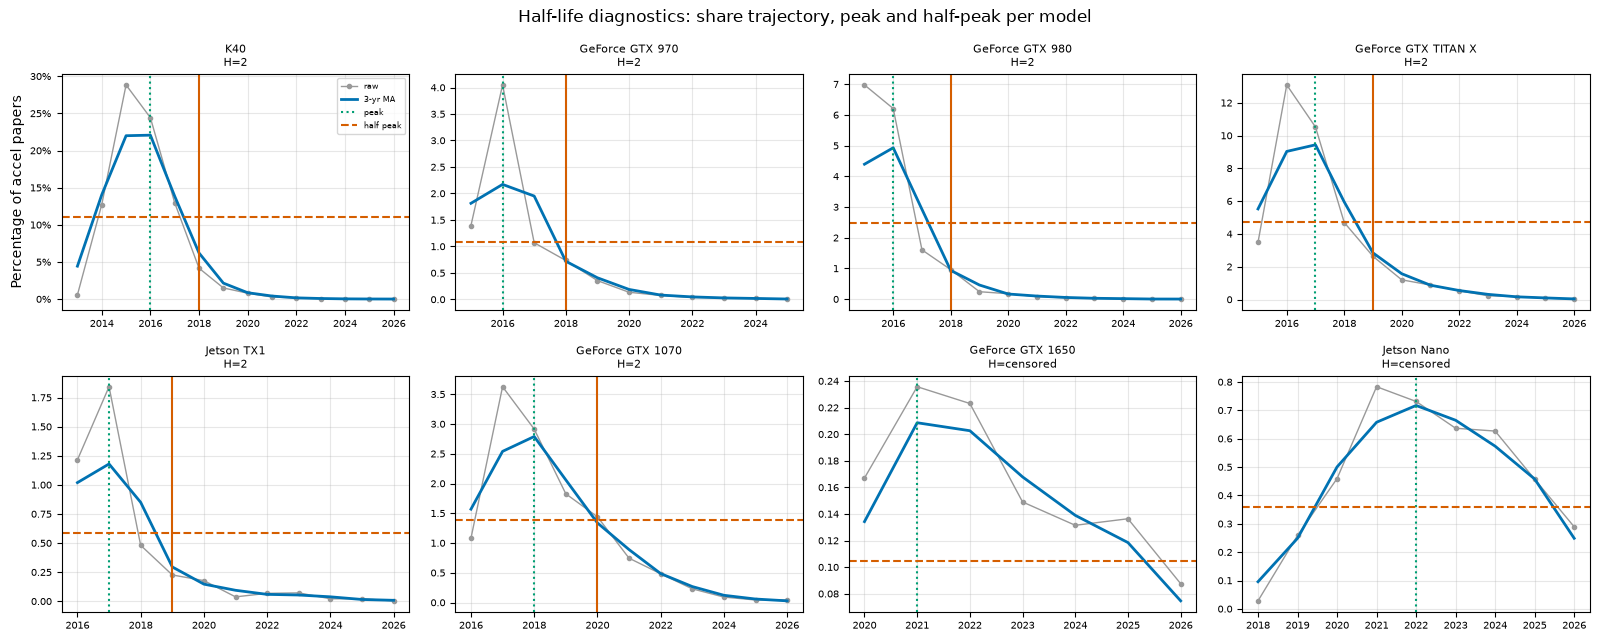

In [7]:
show = obs.head(6)['canonical_model'].to_list() + \
       hl.filter(pl.col('censored')).head(2)['canonical_model'].to_list()
fig, axes = plt.subplots(2, 4, figsize=(16, 6.5))
for ax, mid in zip(axes.ravel(), show):
    s = shares.filter(pl.col('canonical_model') == mid).sort('year')
    yy = s['year'].to_numpy(); vv = s['share'].to_numpy().astype(float)
    r = hl.filter(pl.col('canonical_model') == mid).row(0, named=True)
    ax.plot(yy, 100 * vv, marker='.', color='#999999', lw=1, label='raw')
    ax.plot(yy, 100 * smooth(vv), color='#0072B2', lw=2, label=f'{SMOOTH}-yr MA')
    ax.axvline(r['peak_year'], color='#009E73', ls=':', label='peak')
    ax.axhline(100 * r['peak_share'] / 2, color='#D55E00', ls='--', label='half peak')
    if r['half_life'] is not None:
        ax.axvline(r['peak_year'] + r['half_life'], color='#D55E00', lw=1.5)
    ax.set_title(f"{r['display'].replace('NVIDIA ','')}\n"
                 f"H={'censored' if r['censored'] else r['half_life']}", fontsize=8)
    ax.tick_params(labelsize=7); ax.grid(alpha=0.3)
axes[0, 0].set_ylabel('Percentage of accel papers'); axes[0, 0].legend(fontsize=6)
fig.suptitle('Half-life diagnostics: share trajectory, peak and half-peak per model')
plt.tight_layout(); plt.show()

## 6.3 Adoption lag by generation

Months from commercial release to first scientific mention, and to the 10th and
100th supporting paper. Plotted against release year: a downward slope means
science is absorbing each new generation faster than the last.

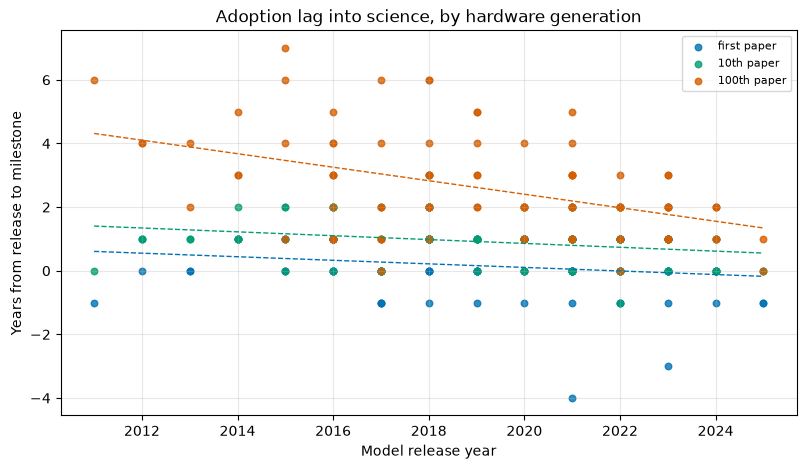

shape: (91, 6)
┌──────────────────────────────────┬──────────────┬────────────┬───────────┬────────┬─────────┐
│ display                          ┆ release_year ┆ segment    ┆ lag_first ┆ lag_10 ┆ lag_100 │
│ ---                              ┆ ---          ┆ ---        ┆ ---       ┆ ---    ┆ ---     │
│ str                              ┆ i64          ┆ str        ┆ i64       ┆ i64    ┆ i64     │
╞══════════════════════════════════╪══════════════╪════════════╪═══════════╪════════╪═════════╡
│ NVIDIA C2050                     ┆ 2011         ┆ datacenter ┆ -1        ┆ 0      ┆ 6       │
│ Intel Xeon Phi                   ┆ 2012         ┆ datacenter ┆ 1         ┆ 1      ┆ 4       │
│ NVIDIA K20                       ┆ 2012         ┆ datacenter ┆ 0         ┆ 1      ┆ 4       │
│ NVIDIA K40                       ┆ 2013         ┆ datacenter ┆ 0         ┆ 1      ┆ 2       │
│ NVIDIA GeForce GTX TITAN         ┆ 2013         ┆ consumer   ┆ 0         ┆ 1      ┆ 4       │
│ NVIDIA K80             

In [8]:
rows = []
for mid in elig['canonical_model']:
    d = meta.filter(pl.col('canonical_model') == mid).row(0, named=True)
    if not d['release_year']:
        continue
    s = (pm.filter(pl.col('canonical_model') == mid)
         .group_by('year').agg(k=pl.col(KEY).n_unique()).sort('year'))
    if not s.height:
        continue
    cum, milestones = 0, {}
    for y, k in zip(s['year'], s['k']):
        cum += k
        for thr in (1, 10, 100):
            if thr not in milestones and cum >= thr:
                milestones[thr] = y - d['release_year']
    rows.append({'display': d['display'], 'release_year': d['release_year'],
                 'segment': d['segment'],
                 'lag_first': milestones.get(1), 'lag_10': milestones.get(10),
                 'lag_100': milestones.get(100)})
lag = pl.DataFrame(rows).filter(pl.col('lag_first').is_not_null())
fig, ax = plt.subplots(figsize=(9.5, 5))
for lbl, col, c in [('first paper', 'lag_first', '#0072B2'),
                    ('10th paper', 'lag_10', '#009E73'),
                    ('100th paper', 'lag_100', '#D55E00')]:
    s = lag.filter(pl.col(col).is_not_null())
    ax.scatter(s['release_year'], s[col], s=22, label=lbl, color=c, alpha=0.8)
    if s.height > 3:
        z = np.polyfit(s['release_year'].to_numpy(), s[col].to_numpy().astype(float), 1)
        xs = np.array([s['release_year'].min(), s['release_year'].max()])
        ax.plot(xs, np.polyval(z, xs), color=c, ls='--', lw=1)
ax.set(xlabel='Model release year', ylabel='Years from release to milestone',
       title='Adoption lag into science, by hardware generation')
ax.legend(fontsize=8); ax.grid(alpha=0.3); plt.show()
with pl.Config(tbl_rows=30, fmt_str_lengths=34):
    print(lag.sort('release_year'))

### Validity check: pre-release mentions

A paper cannot legitimately use a chip released after it was published, so the
pre-release rate is a direct measurement-validity probe (the plan requires
flagging, not silently dropping, these).

The rate for this corpus is computed below. arXiv years are derived from the
id, i.e. the v1 submission month, so the S2ORC metadata errors behind its
~0.08% do not apply here; what remains is a genuine preprint effect (a paper
posted before a chip ships, then revised) plus registry release dates that are
a year off. Negligible for aggregate trends, but they distort `lag_first` in the
adoption-lag table above, which is why lags there should be read with the
pre-release rows excluded.

In [9]:
# pre-release audit + clipped adoption lags
pmv = pm.filter(pl.col('release_year').is_not_null() & (pl.col('year') >= 1990))
pmv = pmv.with_columns(gap=pl.col('year') - pl.col('release_year'))
pre = pmv.filter(pl.col('gap') < 0)
print(f'used-model observations (year >= 1990): {pmv.height:,}')
print(f'pre-release: {pre.height:,} ({100*pre.height/pmv.height:.3f}%)')
print(pre.group_by('gap').len().sort('gap'))
print('\nmost affected models:')
print(pre.group_by('display').len().sort('len', descending=True).head(8))
bad_year = pm.filter(pl.col('year') < 1990)
print(f'\npapers with implausible year (<1990), excluded here: {bad_year.height}')

lag_clean = (lag.with_columns(
    pl.col('lag_first').clip(0, None), pl.col('lag_10').clip(0, None),
    pl.col('lag_100').clip(0, None)))
print('\nadoption lag (pre-release clipped to 0), medians by release era:')
print(lag_clean.with_columns(
        era=pl.when(pl.col('release_year') < 2015).then(pl.lit('pre-2015'))
        .when(pl.col('release_year') < 2020).then(pl.lit('2015-2019'))
        .otherwise(pl.lit('2020+')))
      .group_by('era').agg(n=pl.len(), med_first=pl.col('lag_first').median(),
                           med_10=pl.col('lag_10').median(),
                           med_100=pl.col('lag_100').median()).sort('era'))

used-model observations (year >= 1990): 198,141
pre-release: 51 (0.026%)
shape: (4, 2)
┌─────┬─────┐
│ gap ┆ len │
│ --- ┆ --- │
│ i32 ┆ u32 │
╞═════╪═════╡
│ -4  ┆ 1   │
│ -3  ┆ 1   │
│ -2  ┆ 2   │
│ -1  ┆ 47  │
└─────┴─────┘

most affected models:
shape: (8, 2)
┌────────────────────────────┬─────┐
│ display                    ┆ len │
│ ---                        ┆ --- │
│ str                        ┆ u32 │
╞════════════════════════════╪═════╡
│ NVIDIA GeForce RTX 3090 Ti ┆ 12  │
│ NVIDIA C2050               ┆ 8   │
│ NVIDIA GeForce RTX 5090    ┆ 5   │
│ NVIDIA RTX A1000           ┆ 3   │
│ NVIDIA A100                ┆ 3   │
│ NVIDIA GeForce GTX 1080 Ti ┆ 2   │
│ NVIDIA GeForce RTX 5070 Ti ┆ 1   │
│ NVIDIA Titan RTX           ┆ 1   │
└────────────────────────────┴─────┘

papers with implausible year (<1990), excluded here: 0

adoption lag (pre-release clipped to 0), medians by release era:
shape: (3, 5)
┌───────────┬─────┬───────────┬────────┬─────────┐
│ era       ┆ n   ┆ med_first ┆